In [1]:
import numpy as np
from scipy.stats import norm, kurtosis, shapiro, combine_pvalues
from scipy.stats import t as studt
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import seaborn as sns
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox
from hurst import compute_Hc

Let us consider the simple FIGARCH(p, d, q) model where:

$\beta(L)(1 - L)^d h_{t} = \omega + (1 - \phi (L)) r_t^2$, where we simulate FIGARCH(1, d, 0) so $\beta(L) = 1 - \beta L$ and $q=0$ so $\phi(L) = 0$. Simplifying we have:

$(1 - \beta L)(1-L)^dh_t = \omega + r_t^2$. Taking inverse of fractional operator and using fact that fractinal operator of a constant is the constant we find:

$(1-\beta L)h_t = \omega + (1-L)^{-d} r_t^2$. Using Binomial expansion we have:

$(1-L)^d = 1 = dL + \frac{d(d-1)}{2!}L^2 - \dots = \sum_{k=0}^\infty (-1)^k \binom{d}{k}L^k$. We add $-d$ instead and then we can rewrite the fractional term as:

$\sum_{k=0}^{\infty} \gamma_k r_{t-k}^2$ where $\gamma_0 = 1$, $\gamma_1 = d$, $\gamma_2 = \frac{d(d+1)}{2}$ etc resulting in the recurrence relation:

$\gamma_k = \frac{k-1+d}{k} \gamma_{k-1}$. Finally, since we cannot use return at t to forecast conditional vol at t we start sum from $k=1$ and truncate to some large lag $M=1000$.

The specification follows:

$\hat{h}_{t+1} = \omega + \beta h_t + \sum_{k=1}^M \gamma_k r_{t-k}^2$.

Finally, according to literature we have constraints to ensure conditional variance remains positive and we have a weakly stationary process. We enforce in our paramater selection:

$\omega \geq 0$ ; $0 < d < 1$ ; $d - \beta > 0$.

The above is not correct - see overleaf.

Try setting parameters for daily vol and do not use dt. Remove bias with -0.5 sigma^2 when doing price.

In [2]:
def simulate_figarch(beta, omega, d, N, S0, h0, M):

    r = np.zeros(N)
    h = np.zeros(N)
    h[0] = h0
    logS = np.zeros(N)
    logS[0] = np.log(S0)

    gamma = np.zeros(M+1)
    gamma[0] = 1.0
    for k in range(1, M+1):
         gamma[k] = ((k - 1 - d) / k) * gamma[k-1]
    gamma = gamma[1:] 

    for t in range(N):

            if t==0: 
                r[t] = np.sqrt(h[t]) * norm.rvs()

            else:

                recent_returns2 = r[max(0, t - M): t][::-1] ** 2
                fractional_term = gamma[:recent_returns2.shape[0]] @ recent_returns2
                h[t] = omega + beta * (h[t-1] - r[t-1]**2) - fractional_term
                r[t] = np.sqrt(h[t]) * norm.rvs()
                logS[t] = logS[t-1] - 0.5 * h[t] + r[t] # remove bias 

    S = np.exp(logS)

    return r, h, S

In this implementation the params are all daily ones!!! This v key and really skews results when not thought about in terms of extreme spots and no long memory!

In [ ]:
beta = np.array([0.25])
d = np.array([0.45])
omega = np.array([2e-4 / 252])
sigma = np.sqrt(omega / (1 - beta))
#sigma = np.array([0.15 / np.sqrt(252)])

N = 10_000
npaths = 500
r_t = np.zeros((N, npaths))
h_t = np.zeros((N, npaths))
h0 = sigma ** 2
S_t = np.zeros((N, npaths))
S0 = 10
M = 500

In [4]:
for i in range(npaths):
    r_t[:, i], h_t[:, i], S_t[:, i] = simulate_figarch(beta, omega, d, N, S0, h0, M)

/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_25557/1736110453.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  h[0] = h0
/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_25557/1736110453.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[k] = ((k - 1 - d) / k) * gamma[k-1]
/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_25557/1736110453.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  h[t] = omega + beta * (h[t-1] -

In [16]:
np.savez("all_paths_figarch_d_8.npz", r=r_t, h=h_t, S=S_t)

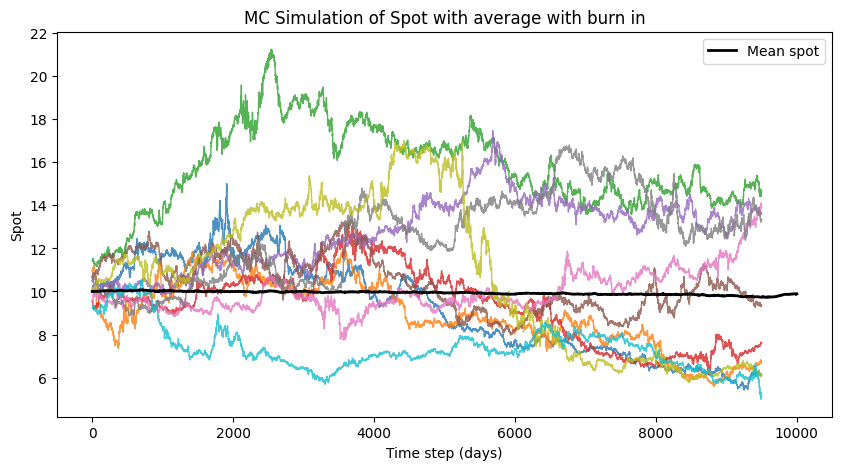

In [5]:
plt.figure(figsize=(10, 5))
for k in range(4, 14):
    plt.plot(S_t[M:, k], linewidth = 1, alpha = 0.8)

mean_price = np.mean(S_t, axis = 1)
plt.plot(mean_price, "-k", label = "Mean spot", linewidth = 2)
plt.xlabel("Time step (days)")
plt.ylabel("Spot")
plt.title("MC Simulation of Spot with average with burn in")
plt.legend()

/var/folders/ws/xbf0f9zj4qxc6drt1bjn4lg40000gn/T/ipykernel_8069/3208074933.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


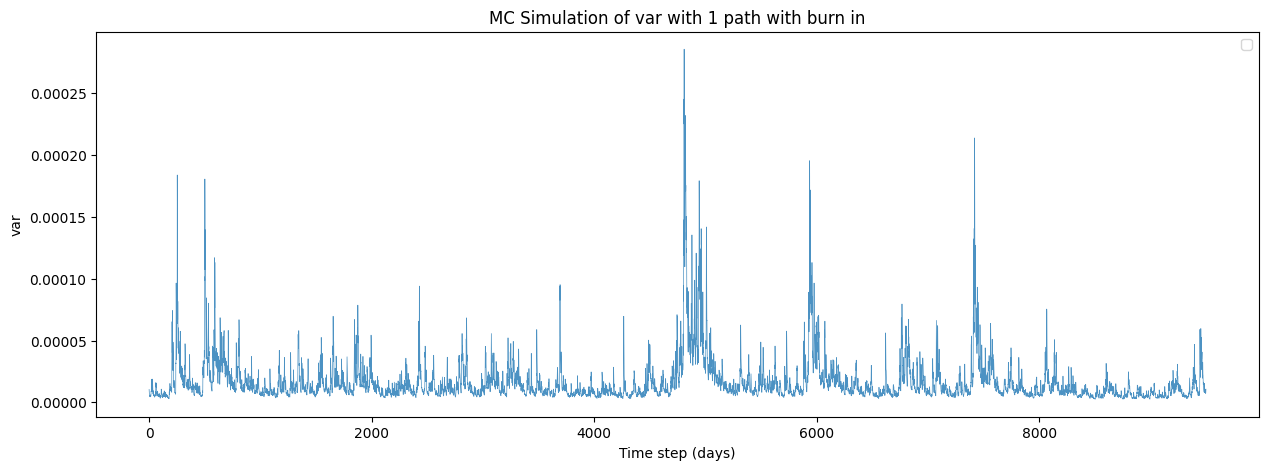

In [6]:
plt.figure(figsize=(15, 5))
plt.plot(h_t[M:, 0], linewidth = 0.5, alpha = 0.8)


plt.xlabel("Time step (days)")
plt.ylabel("var")
plt.title("MC Simulation of var with 1 path with burn in")
plt.legend()

## Use absolute or squared returns for long memory ACF not variance?

Mismatch occurs when you scale variance from figarch by dt as diminishes long memory so instead we simulate daily variance using the model.

In [7]:
def compute_acf(x, lags):
    x_mean = x.mean()
    y = x - x_mean

    acf_vals = np.zeros(lags)
    acf_vals[0] = 1.0
    for i in range(1, lags):

        acf_vals[i] = (np.dot(y[i:], y[:-i])) / np.dot(y, y)

    return acf_vals

We need confidence bands and since we do not have white noise we cannot use simple +-z/root(N) case and must use Bartlett Confidence bands. 

Using the Introduction to Statistical Learning book we can find the formula $\hat{\rho} \approx N(\rho, n^{-1}W)$ and elements of $W$ are given by Bartlett's formula. Since we consider only one lag ie X_t compared to X_{t+tao} the formula simplifies so that for lag h we only need:

$w_{hh} = \sum_{k=1}^\infty (\rho(k+h) + \rho(k - h) - 2\rho(h)\rho(k))^2$, where infinty is actually total number of lags used. For MA(q) time series book by Brockwell and Davis collapses this to:

$w_{ii} = 1 + 2 \sum_{j=1}^{i-1} \rho(j)^2$, which we will use despite underlying process being FIGARCH. Moreover, we plot the white noise confidence bands to show the extra uncertainity given by using this formula.

Then for each h plot:

$\pm 1.96 \sqrt(w_{hh} / n)$, where n is number of total observations and this is for 95%.

In [8]:
def get_confd_bands(n_obs, acfs, alpha = 0.05):
    '''
    Assuming underlying process is MA(q) we use this.
    '''


    K = len(acfs)
    z = norm.ppf(1 - alpha/2)
    lower = np.zeros(K)
    upper = np.zeros(K)

    for h in range(1, K):
        var_h = (1 + 2*np.sum(acfs[1:h]**2)) / n_obs
        halfwidth = z * np.sqrt(var_h)
        lower[h] = -halfwidth
        upper[h] =  halfwidth

    return lower, upper

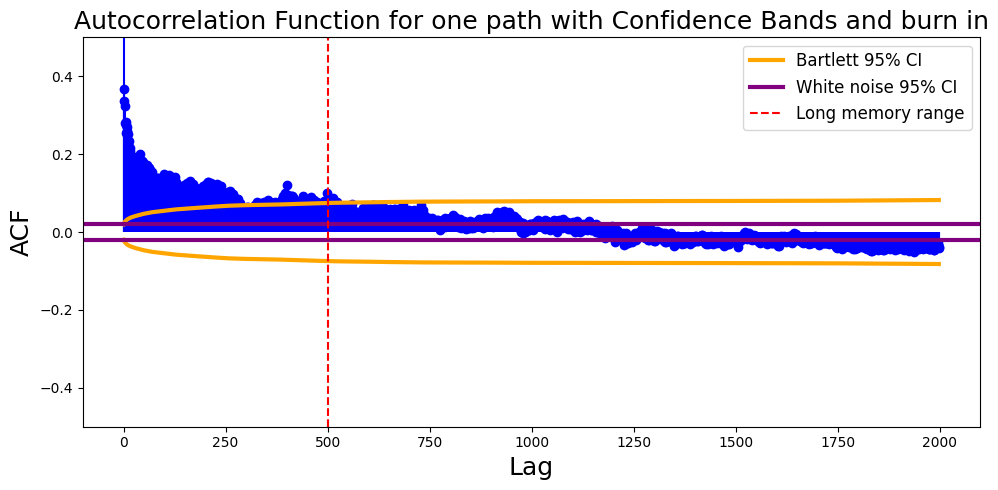

In [26]:
lags = 2000
x = abs(r_t[M:, 3])
n_obs = len(x)

acf_vals = compute_acf(x, lags)
lo, up = get_confd_bands(n_obs, acf_vals)

other = 1.96 / np.sqrt(n_obs)

plt.figure(figsize=(10, 5))
plt.stem(range(0, lags), acf_vals[0:], linefmt='b-', markerfmt='bo', basefmt=' ')
plt.plot(up[1:], '-',color = 'orange', linewidth = 3,  label = "Bartlett 95% CI")
plt.plot(lo[1:], "-", color = "orange", linewidth = 3)
plt.axhline(y = other, color = "purple", linewidth = 3, label = "White noise 95% CI")
plt.axhline(y = -other, color = "purple", linewidth = 3)
plt.axvline(x=M, color='red', linestyle='--', label='Long memory range')
plt.ylim([-0.5, 0.5])
plt.xlabel('Lag', fontsize = 18)
plt.ylabel('ACF', fontsize = 18)
plt.title('Autocorrelation Function for one path with Confidence Bands and burn in', fontsize = 18)
plt.tight_layout()
plt.legend(fontsize = 'large')
plt.savefig("/Users/alexvillamartin/Documents/MSc Diss/Plots/ACF_figarch")
plt.show()


The major peaks at very short lags is an indicator of vol clustering as previous low/high values are clearly correlated with current low/high ones. The continued persistence of ACF at longer lags up to the long memory range hard coded is representative of long memory.

## Quantify clustering and fat tails

Fat tails - QQ plots

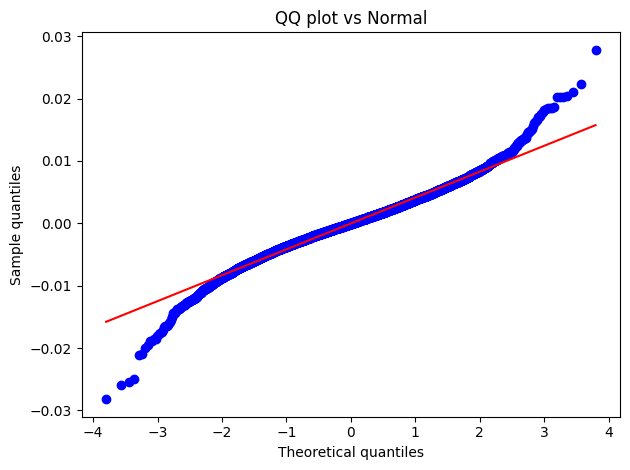

In [97]:
X = r_t[M:, 5]  # leave burn in 

stats.probplot(X, dist="norm", plot=plt)
plt.title("QQ plot vs Normal")
plt.xlabel("Theoretical quantiles")
plt.ylabel("Sample quantiles")
plt.tight_layout()
plt.show()


Depends on which path we choose.

In [25]:
Exkurts = np.zeros(npaths)
for i in range(npaths):
    Exkurts[i] = kurtosis(r_t[M:, i], fisher=True) 

print(f"Mean excess kurt over {npaths} paths: {Exkurts.mean()}")

Mean excess kurt over 500 paths: 5.508461070560889


Do shapiro Wilk, vol clustering test, apply to heston and ms-garch including adding the -0.5 sigma^2 term if required - write this up summarising properties of these simulations. 

To further look into fat tails let us do Shapiro Wilk test - H0: sample is Gaussian so we look for a small p value to reject the null.

In [29]:
ps = []

for i in range(npaths):

    stat, p = shapiro(r_t[M:, i])
    ps.append(p)

print(f"Mean p-value of Shapiro Wilk: {np.mean(ps)}")

bonf_corr = 0.1 / npaths
print(f"Bonf Corr: {bonf_corr}")

Mean p-value of Shapiro Wilk: 0.0379419509100729
Bonf Corr: 0.0002


Based on Bonferroni corection we cannot reject Gaussian but intuitively we see generally low p-values suggesting we do not have a complete Gaussian distribution and the presence of fat tails whilst not major is present to a certain extent - this can also be emphasised with different paramaters so this test is not absolute truth.

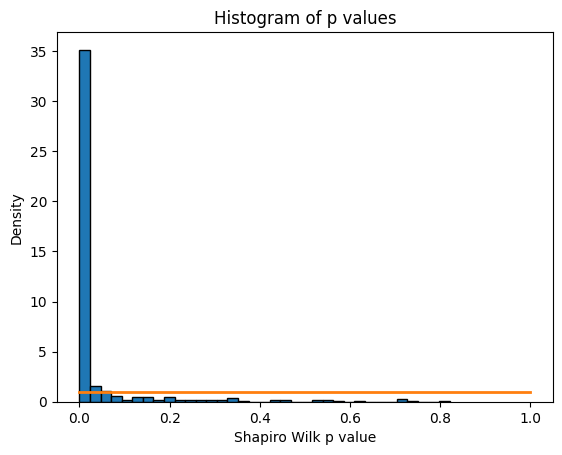

In [22]:
plt.hist(ps, bins=35, density=True, edgecolor='k')
plt.plot([0,1], [1,1], lw=2)      
plt.xlabel('Shapiro Wilk p value')
plt.ylabel('Density')
plt.title('Histogram of p values')
plt.show()

In [27]:
B = 10_000
boot_means = np.mean(np.random.choice(ps, (B, len(ps)), replace=True), axis=1)
ci_low, ci_high = np.percentile(boot_means, [2.5, 97.5])
print(f"Bootstrap 95% CI for mean p-value: [{ci_low:.3f}, {ci_high:.3f}]")

Bootstrap 95% CI for mean p-value: [0.028, 0.049]


To build upon vol clustering we can do the Ljung-Box test to test whether the data exhibits serial correlation (which it clearly does) and secondly we could build upon long memory by computing hurst exponent to see if we have persistence. 

In [23]:
# as mentioned vol clustering will present itself as autocorreltaions at short lags
lags = 10

ps = []

for i in range(npaths):

    res = acorr_ljungbox(abs(r_t[M:, i]), lags = lags, return_df=True)
    ps.append(res['lb_pvalue'].iloc[-1])

print(f"Mean p-value of Ljung Box test: {np.mean(ps)}")

bonf_corr = 0.01 / npaths
print(f"Bonf Corr: {bonf_corr}")

Mean p-value of Ljung Box test: 0.0
Bonf Corr: 2e-05


Instead of finding mean pvalue as isnt that rigorous let us use Fisher method for combining p-values of indepednent test stats (which includes simulated paths). 

In [24]:
fisher_p   = combine_pvalues(ps, method='fisher')[1]
fisher_p

/Users/alexvillamartin/Documents/MSc Diss/Code/.venv/lib/python3.13/site-packages/scipy/stats/_stats_py.py:8980: RuntimeWarning: divide by zero encountered in log
  statistic = -2 * xp.sum(xp.log(pvalues), axis=axis)


np.float64(0.0)

Focusing on hurst for long-memery : intersting as will this not be 0.5 - maybe for returns yes but for abs returns we will have persistence. Use MF-DFA for hurst as more reliable than R/S. Also, we added no drift so no specific cleaning is required before we strat the DFA.

In [79]:
from MFDFA_functions import get_moment_fluctuations_q, get_generalised_hurst, get_mf_spectrum

In [80]:
def get_hurst(data):
    '''
    Use my MF-DFA functions to get hurst exponent only.
    '''

    X = data
    N = len(X)
    s_min = 10
    s_max = len(X) // 4
    q = 2 # reccomended in lit for between -6 and 6
    m= 1
    steps = 40
    mu_X = np.mean(X)
    Y = np.cumsum(X - mu_X)

    F_q, ss, _, _, _ = get_moment_fluctuations_q(q=q, s_min=s_min, s_max = s_max, Y=Y, m=m, numb_ss = steps)

    H = get_generalised_hurst(F_q = F_q, ss = ss)

    return H


In [101]:
hursts_r = []
hursts_abs_r = []

for i in range(npaths):
    H_r = get_hurst(data = r_t[M:, i])
    H_abs_r = get_hurst(data = abs(r_t[M:, i]))
    hursts_r.append(H_r)
    hursts_abs_r.append(H_abs_r)              

In [102]:
print(f"Hurst average on returns: {np.mean(hursts_r)}")
print(f"Hurst average on absolute returns: {np.mean(hursts_abs_r)}")

Hurst average on returns: 0.4965327247480745
Hurst average on absolute returns: 0.8778112761220143


We see long memeory in abs returns but none in returns confirming that styalised fact. 

## MF-DFA

In [5]:
from MFDFA_functions import get_moment_fluctuations_q, get_generalised_hurst, get_mf_spectrum

In [8]:
X = np.abs(r_t[M:, 0]) # leave burn in
N = len(X)
s_min = 10
s_max = len(X) // 4
qs = np.arange(-10, 11,1) # reccomended in lit for between -6 and 6
m= 1
steps = 40
mu_X = np.mean(X)
Y = np.cumsum(X - mu_X)

In [103]:
X = r_t[M:, 0] # leave burn in
N = len(X)
s_min = 10
s_max = len(X) // 4
qs = np.arange(-6, 7,1) # reccomended in lit for between -6 and 6
m= 1
steps = 40
mu_X = np.mean(X)
Y = np.cumsum(X - mu_X)

In [9]:
F_qs = list()
fitss1 = list()
fitss2 = list()

for q in qs: 

    F_q, ss, fits1, fits2, buffer = get_moment_fluctuations_q(q=q, s_min=s_min, s_max = s_max, Y=Y, m=m, numb_ss = steps)
    F_qs.append(F_q)
    
    if q == 2:
        
        fitss1.append(fits1)
        fitss2.append(fits2)

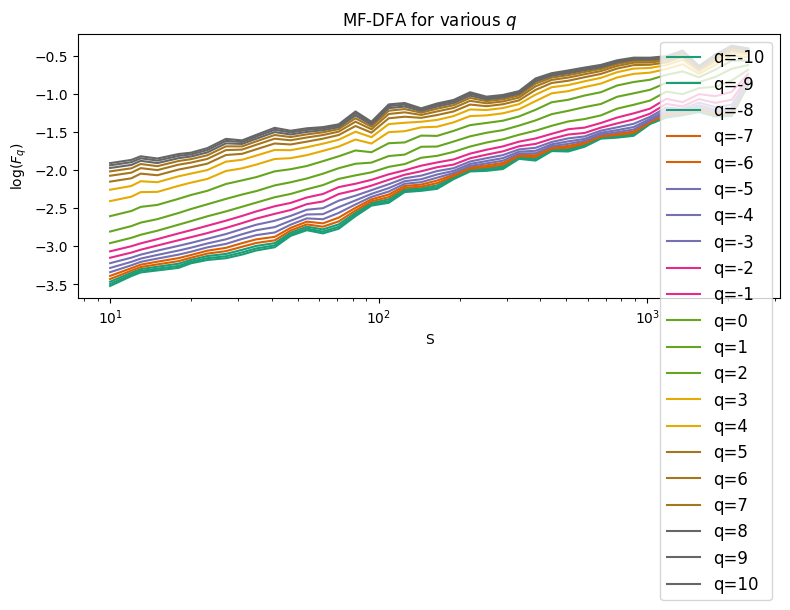

In [10]:
colors = plt.cm.Dark2(np.linspace(0, 1, len(qs)))

plt.figure(figsize = (8, 5))
for q_val, Fq, c in zip(qs, F_qs, colors):
    plt.plot((ss), np.log10(Fq), label=f'q={q_val}',  color = c, linewidth = 1.5)
plt.xscale('log')
plt.xlabel('S')
plt.ylabel(r'$\text{log}(F_q)$')
plt.title(r'MF-DFA for various $q$')
plt.legend(fontsize = "large")
plt.tight_layout()
plt.show()

Text(0.5, 0, 'Days')

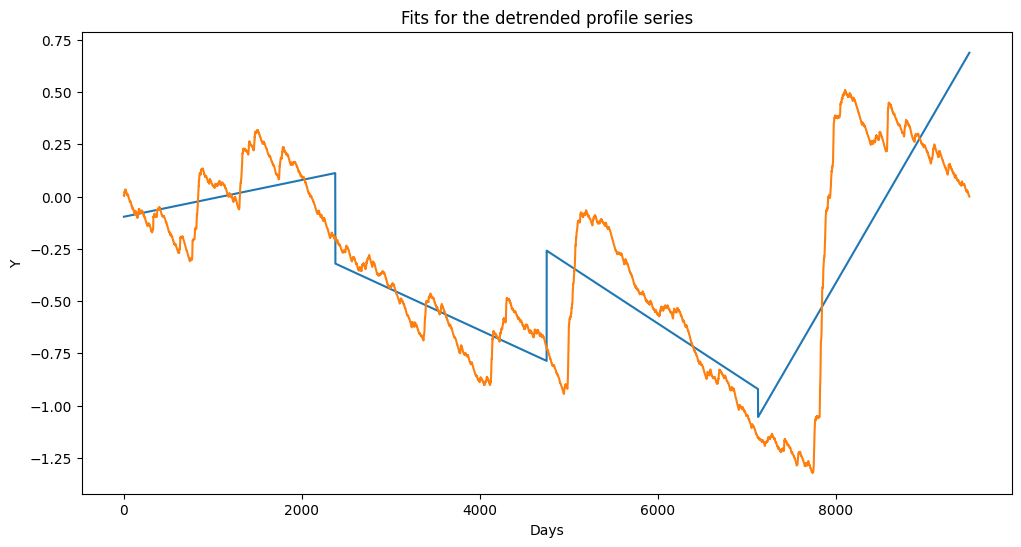

In [11]:
plt.figure(figsize = (12, 6))

y1 = np.concatenate(fitss1).flatten()
y2 = np.concatenate(fitss2).flatten()
t = np.arange(0, N, 1)
plt.plot(t, y1)
plt.plot(Y)
plt.title("Fits for the detrended profile series")
plt.ylabel("Y")
plt.xlabel("Days")

In [12]:
generalised_H = np.zeros(len(qs))

for i in range(len(F_qs)): 

    generalised_H[i] = get_generalised_hurst(F_q = F_qs[i], ss = ss)

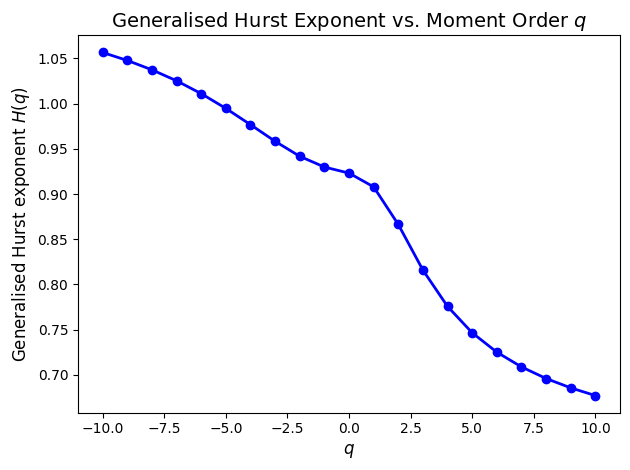

In [13]:
plt.plot(qs, generalised_H, linestyle='-', marker='o', markersize=6, linewidth=2, color='b')
plt.xlabel(r'$q$', fontsize=12)
plt.ylabel(r'Generalised Hurst exponent $H(q)$', fontsize=12)
plt.title(r'Generalised Hurst Exponent vs. Moment Order $q$', fontsize=14)
plt.tight_layout()
plt.show()

Not much variation at all!

In [14]:
tao_q, alpha_q, f_alpha = get_mf_spectrum(generalised_H, qs)

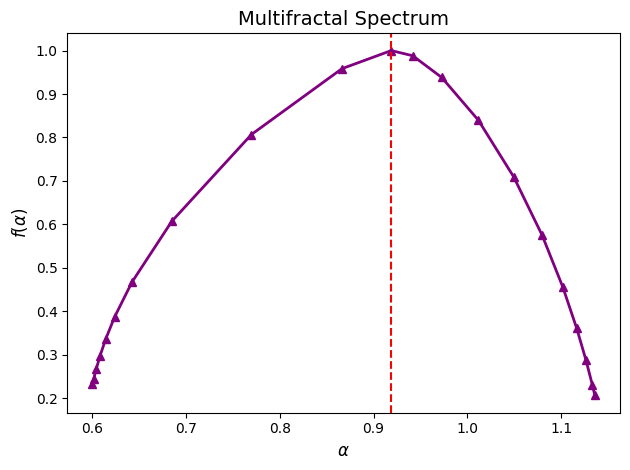

In [15]:
f_alpha_max_idx = np.argmax(f_alpha)

plt.plot(alpha_q, f_alpha, marker='^', markersize=6, linewidth=2, color='purple')
plt.xlabel(r'$\alpha$', fontsize=12)
plt.ylabel(r'$f(\alpha)$', fontsize=12)
plt.title(r'Multifractal Spectrum', fontsize=14)
plt.axvline(x=alpha_q[f_alpha_max_idx], color='red', linestyle='--', label='max f_alpha')
plt.tight_layout()
plt.show()